In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!
import pickle
import datetime
from logic import gwyfile as gwy
import numpy as np
from scipy.signal import find_peaks

In [29]:
filebeginning = '20250828-1548-37_T1-dark-init-alt-exp-point-by-point_A-F17-26_NbSe2_S6_2.5K_70mT_Bnv_sFC_Z_lift_off_5e-09_thick_region_vortex_scan52_x9.61um_y11.13um_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\PulsedMeasurement\\'
filepath = path + filebeginning + '.dat'

In [30]:
data_pulsed = np.loadtxt(filepath).T
# pulsedmeasurementlogic_AWG.signal_data[1] = data_raw[1]
# pulsedmeasurementlogic_AWG.measurement_error[1] = data_raw[3]
# pulsedmeasurementlogic_AWG.signal_data[2] = data_raw[2]
# pulsedmeasurementlogic_AWG.measurement_error[2] = data_raw[4]

In [35]:
tau_arr = data_pulsed[0,:26]

In [41]:
tau_arr.shape

(26,)

In [45]:
alternating = True
freq_sweep = False
tau_num = len(tau_arr) * 2 if alternating else len(tau_arr)
pjl.pulsed_master_AWG.set_fast_counter_settings(record_length=pjl.read_out_time+pjl.add_tt_read_out, number_of_gates=tau_num)
pjl.pulsed_master_AWG.set_measurement_settings(invoke_settings=False, 
                            controlled_variable=tau_arr,
                            number_of_lasers=tau_num, 
                            laser_ignore_list=[], 
                            alternating=alternating, 
                            units=('Hz' if freq_sweep else 's', 'arb. u.'))
pjl.pulsed_master_AWG.pulsedmeasurementlogic().alternative_data_type = 'None'

In [46]:
pjl.pulsed_measurement_logic_AWG._initialize_data_arrays()

In [39]:
def update_pulsed_gui(elapsed_time, elapsed_sweeps, raw_data):
    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_time = elapsed_time
    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = elapsed_sweeps
    pulsedmeasurementlogic_AWG.raw_data = raw_data
    
    return_dict = pulsedmeasurementlogic_AWG._pulseextractor.extract_laser_pulses(pulsedmeasurementlogic_AWG.raw_data)
    pulsedmeasurementlogic_AWG.laser_data = return_dict['laser_counts_arr']

    tmp_signal, tmp_error = pulsedmeasurementlogic_AWG._analyze_laser_pulses()

    # exclude laser pulses to ignore
    if len(pulsedmeasurementlogic_AWG._laser_ignore_list) > 0:
        # Convert relative negative indices into absolute positive indices
        while pulsedmeasurementlogic_AWG._laser_ignore_list[0] < 0:
            neg_index = pulsedmeasurementlogic_AWG._laser_ignore_list[0]
            pulsedmeasurementlogic_AWG._laser_ignore_list[0] = len(tmp_signal) + neg_index
            pulsedmeasurementlogic_AWG._laser_ignore_list.sort()

        tmp_signal = np.delete(tmp_signal, pulsedmeasurementlogic_AWG._laser_ignore_list)
        tmp_error = np.delete(tmp_error, pulsedmeasurementlogic_AWG._laser_ignore_list)

    # order data according to alternating flag
    if pulsedmeasurementlogic_AWG._alternating:
        if len(pulsedmeasurementlogic_AWG.signal_data[0]) != len(tmp_signal[::2]):
            pulsedmeasurementlogic_AWG.log.error('Length of controlled variable ({0}) does not match length of number of readout '
                           'pulses ({1}).'.format(len(pulsedmeasurementlogic_AWG.signal_data[0]), len(tmp_signal[::2])))
            return
        pulsedmeasurementlogic_AWG.signal_data[1] = tmp_signal[::2]
        pulsedmeasurementlogic_AWG.signal_data[2] = tmp_signal[1::2]
        pulsedmeasurementlogic_AWG.measurement_error[1] = tmp_error[::2]
        pulsedmeasurementlogic_AWG.measurement_error[2] = tmp_error[1::2]
    else:
        if len(pulsedmeasurementlogic_AWG.signal_data[0]) != len(tmp_signal):
            pulsedmeasurementlogic_AWG.log.error('Length of controlled variable ({0}) does not match length of number of readout '
                           'pulses ({1}).'.format(len(pulsedmeasurementlogic_AWG.signal_data[0]), len(tmp_signal)))
            return
        pulsedmeasurementlogic_AWG.signal_data[1] = tmp_signal
        pulsedmeasurementlogic_AWG.measurement_error[1] = tmp_error

    # Compute alternative data array from signal
    pulsedmeasurementlogic_AWG._compute_alt_data()

    # emit signals
    pulsedmeasurementlogic_AWG.sigTimerUpdated.emit(pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_time, pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps,
                          pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__timer_interval)
    pulsedmeasurementlogic_AWG.sigMeasurementDataUpdated.emit()

In [47]:
update_pulsed_gui(10800, 100000, data_raw_snip)

100%|#################################################################################| 1/1 [17:28:43<00:00, 62923.41s/it]


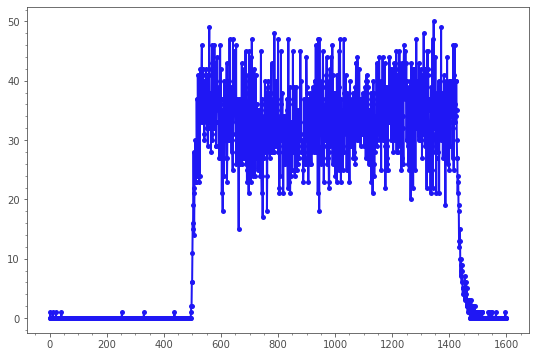

In [28]:
plt.plot(data_raw[51])
plt.show()

In [23]:
data_raw_snip = data_raw[:52]

In [26]:
data_raw_snip.shape

(52, 1600)

In [9]:
data_raw = np.loadtxt(filepath).T
var_list = data_raw[0]

plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize = (5, 4))

plot_option = 3 #1 = Signal1, 2 = Signal2, 3 = delta of signals
err = None

var_list_more = np.linspace(var_list[0],var_list[-1],1000)

#Choose what to plot
if plot_option == 3:
    data = data_raw[1] - data_raw[2]
    shift = (data_raw.shape[0]-1)//2
    err1 = abs(data_raw[1+shift])
    err2 = abs(data_raw[2+shift])
    err = err1+err2
else:
    data = data_raw[plot_option]
    shift = (data_raw.shape[0]-1)//2
    err = data_raw[plot_option+shift]

peaks, _ = find_peaks(data, prominence=(0.02, None))#, distance=20)
peaks = np.insert(peaks, 0, 0, axis=0)
fit_peaks = fitlogic.make_decayexponentialstretched_fit(var_list[peaks],data[peaks],estimator=fitlogic.estimate_decayexponentialstretched)
lm_peaks,_ = fitlogic.make_decayexponentialstretched_model()
temp = lm_peaks.eval(fit_peaks.params, x=var_list_more)
t2s = fit_peaks.params['lifetime']
t2s_err = fit_peaks.params['lifetime'].stderr
beta = fit_peaks.params['beta']
beta_err = fit_peaks.params['beta'].stderr

ax_HE = fig.add_subplot()

ax_HE.set_xlabel('Waiting time (µs)')
ax_HE.set_ylabel('Signal (a.u.)')

ax_HE.errorbar(x=var_list*1e6, y=data/np.max(data),
                         yerr=err, fmt='-o',
                         capsize=3, capthick=0.9,
                        elinewidth=1.2, markersize=3, linewidth=1.0, label="Data")
leg = f"T$_2$: {round(fit_peaks.params['lifetime']*1e6,2)} µs $\pm$ {round(fit_peaks.params['lifetime'].stderr*1e6,2)} µs"
ax_HE.plot(var_list_more*1e6, temp/np.max(temp),'r-', linewidth=1.5, label=leg)

ax_HE.legend()
ax_HE.title.set_text(filebeginning)
ax_HE.title.set_size(5)

plt.tight_layout()

with open(path + filebeginning+'_envelope_fit.png', 'wb') as f:
    plt.savefig(f,format='png')

plt.show()
print(beta)